# 🧹 Data Cleaning, Feature Engineering & Validation
In this notebook, we will:
1. Clean the data (handle missing IDs, drop cancellations for RFM).
2. Engineer RFM (Recency, Frequency, Monetary) features.
3. Calculate rolling statistics.
4. Validate our engineered features using `great_expectations`.

In [25]:
# Loading Libraries
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import great_expectations as gx
import os

import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid")

In [26]:
try:
    from IPython.display import display
except ImportError:
    def display(obj): print(obj)

## 1. Load the Data
We'll load the merged dataset checkpoint we created at the end of the EDA.

In [27]:
try:
    df = pd.read_csv('../data/processed/online_retail_initial.csv', parse_dates=['InvoiceDate'])
    print(f"Successfully loaded {len(df)} rows.")
except FileNotFoundError:
    print("Error: Could not find the processed CSV. Please make sure you ran the save checkpoint cell in the EDA notebook.")
    raise

Successfully loaded 1033035 rows.


## 2. Data Cleaning
For RFM analysis, we need a valid `CustomerID`. We also want to separate standard purchases from returns/cancellations.

In [28]:
missing_ids = df[df['CustomerID'].isnull()]
print(f"🔍 Sample of rows with missing CustomerID ({len(missing_ids):,} total):")
display(missing_ids.head(5))

🔍 Sample of rows with missing CustomerID (235,151 total):


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice,Year,Month,Day,Hour,YearMonth
263,489464,21733,85123a mixed,-96,2009-12-01 10:52:00,0.00,NaN,United Kingdom,-0.00,2009,12,1,10,2009-12
283,489463,71477,short,-240,2009-12-01 10:52:00,0.00,NaN,United Kingdom,-0.00,2009,12,1,10,2009-12
284,489467,85123A,21733 mixed,-192,2009-12-01 10:53:00,0.00,NaN,United Kingdom,-0.00,2009,12,1,10,2009-12
462,489521,21646,NaN,-50,2009-12-01 11:44:00,0.00,NaN,United Kingdom,-0.00,2009,12,1,11,2009-12
569,489525,85226C,BLUE PULL BACK RACING CAR,1,2009-12-01 11:49:00,0.55,NaN,United Kingdom,0.55,2009,12,1,11,2009-12


In [29]:
missing_revenue = missing_ids['TotalPrice'].sum()
total_revenue = df['TotalPrice'].sum()
print(f"\n💸 Revenue from rows with missing CustomerID: £{missing_revenue:,.2f}")
print(f"   That's {missing_revenue/total_revenue*100:.1f}% of total revenue\n")


💸 Revenue from rows with missing CustomerID: £2,565,542.41
   That's 13.6% of total revenue



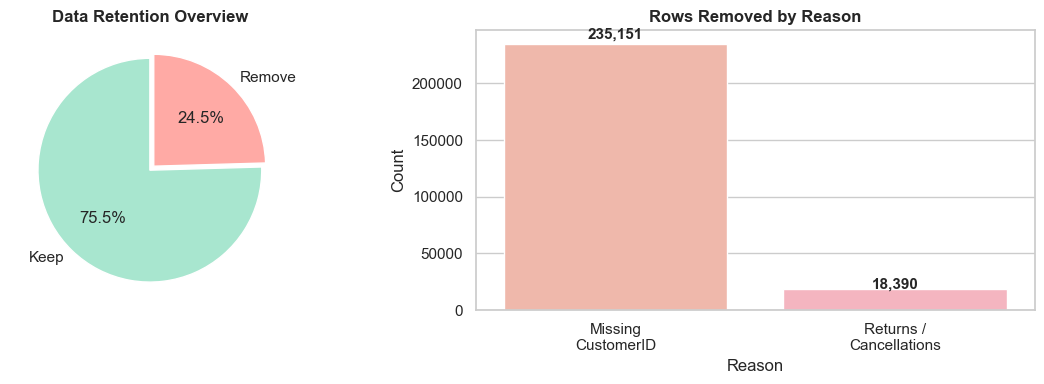

In [30]:
total_rows = len(df)
missing_id_rows = len(missing_ids)
cancellation_rows = (df['CustomerID'].notna()) & (df['Quantity'] <= 0)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
keep = total_rows - missing_id_rows - cancellation_rows.sum()
drop = missing_id_rows + cancellation_rows.sum()
axes[0].pie([keep, drop], labels=['Keep', 'Remove'], colors=['#a8e6cf', '#ffaaa5'], 
            autopct='%1.1f%%', startangle=90, explode=(0, 0.05))
axes[0].set_title('Data Retention Overview', fontsize=12, fontweight='bold')

removal_reasons = pd.DataFrame({
    'Reason': ['Missing\nCustomerID', 'Returns /\nCancellations'],
    'Count': [missing_id_rows, cancellation_rows.sum()]
})
sns.barplot(data=removal_reasons, x='Reason', y='Count', hue='Reason', 
            palette=['#fab1a0', '#ffabb9'], legend=False, ax=axes[1])
axes[1].set_title('Rows Removed by Reason', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Count')

for i, v in enumerate(removal_reasons['Count']):
    axes[1].text(i, v + (v * 0.02), f'{v:,}', ha='center', fontsize=11, fontweight='bold')
plt.tight_layout()
plt.show()

In [31]:
clean_df = df.dropna(subset=['CustomerID']).copy()

In [32]:
# Separate purchases from cancellations 
purchases = clean_df[clean_df['Quantity'] > 0].copy()

In [33]:
print(f"Rows after dropping missing IDs and cancellations: {len(purchases)}")

Rows after dropping missing IDs and cancellations: 779494


> 💡 **Why exclude cancellations from RFM?** Returns and cancellations (`Quantity ≤ 0`) represent reverse transactions, not buying behavior. We drop them so Frequency and Monetary scores reflect genuine purchase intent. The original purchase rows are preserved — the customer *did* buy, even if they returned it later.

## 3. Feature Engineering: RFM Scores
**📊 RFM** stands for **Recency**, **Frequency**, and **Monetary** value.  
It’s a behavior-based customer segmentation method used to rank customers based on:

- 🕒 **Recency**: How recently did the customer purchase? (Days since last purchase)
- 🔁 **Frequency**: How often do they purchase? (Number of unique invoices) 
- 💰 **Monetary**: How much do they spend? (Total sum of purchases)

**We can identify best customers (high F, M) vs. at-risk or loyal but low-spending ones. Common in marketing for targeting, retention, and rewards 🎁**

In [34]:
snapshot_date = purchases['InvoiceDate'].max() + pd.Timedelta(days=1)
snapshot_date

Timestamp('2011-12-10 12:50:00')

> 📅 **Snapshot date:** All Recency values are calculated as days since this date — the day after the last transaction in the dataset. Lower Recency = more recent customer.

In [35]:
# RFM metrics
rfm = purchases.groupby('CustomerID').agg({
    'InvoiceDate': lambda x: (snapshot_date - x.max()).days, # Recency
    'InvoiceNo': 'nunique',                                  # Frequency
    'TotalPrice': 'sum'                                      # Monetary
}).reset_index()

rfm.rename(columns={
    'InvoiceDate': 'Recency',
    'InvoiceNo': 'Frequency',
    'TotalPrice': 'Monetary'
}, inplace=True)

In [36]:
# ---- Drop £0 spenders (free items) ----
rfm = rfm[rfm['Monetary'] > 0]
display(rfm.head())

,CustomerID,Recency,Frequency,Monetary
0,12346.0,326,12,77556.46
1,12347.0,2,8,4921.53
2,12348.0,75,5,2019.40
3,12349.0,19,4,4428.69
4,12350.0,310,1,334.40


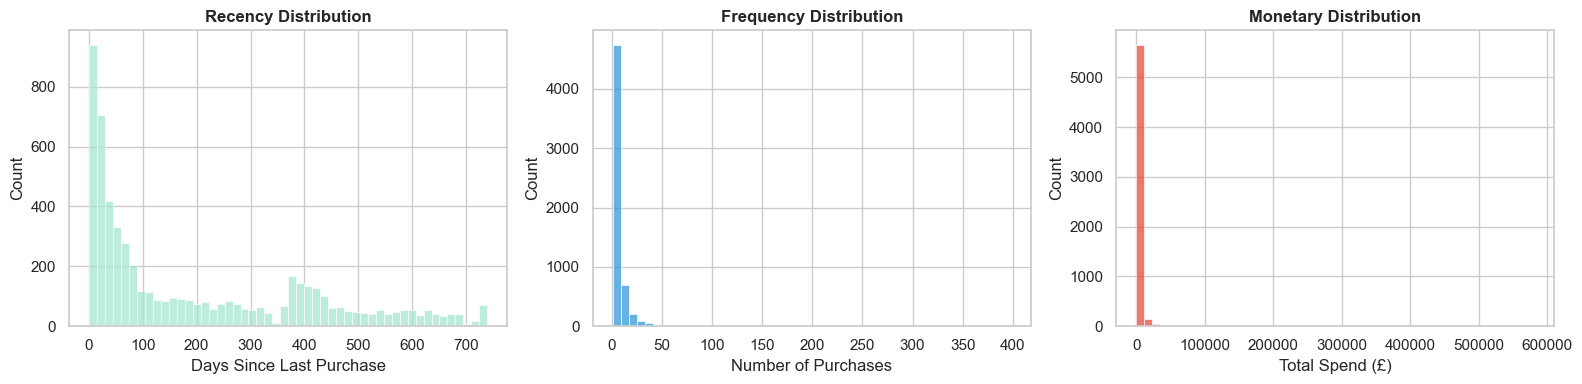

In [37]:
# ---- RFM distributions ----
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

sns.histplot(rfm['Recency'], bins=50, ax=axes[0], color='#a8e6cf')
axes[0].set_title('Recency Distribution', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Days Since Last Purchase')

sns.histplot(rfm['Frequency'], bins=50, ax=axes[1], color='#3498db')
axes[1].set_title('Frequency Distribution', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Number of Purchases')

sns.histplot(rfm['Monetary'], bins=50, ax=axes[2], color='#e74c3c')
axes[2].set_title('Monetary Distribution', fontsize=12, fontweight='bold')
axes[2].set_xlabel('Total Spend (£)')

plt.tight_layout()
plt.show()

## 4. Feature Engineering: Rolling Statistics 📦
We can calculate rolling statistics, such as the 7-day rolling average of daily total revenue, which helps smooth out day-to-day volatility and highlights longer-term trends.

- 🕐 Short window (7d) → captures recent changes

- 📅 Long window (30d) → captures seasonal/base demand

In [38]:
# Getting daily total sales
daily_sales = purchases.groupby(purchases['InvoiceDate'].dt.date)['TotalPrice'].sum().reset_index()
daily_sales['InvoiceDate'] = pd.to_datetime(daily_sales['InvoiceDate'])

In [39]:
daily_sales.tail()

,InvoiceDate,TotalPrice
599,2011-12-05,58081.09
600,2011-12-06,45989.66
601,2011-12-07,69230.60
602,2011-12-08,50395.96
603,2011-12-09,184329.66


**📌 We take 7 consecutive days, add them up, divide by 7**

In [40]:
daily_sales['Rolling_7D_Avg'] = daily_sales['TotalPrice'].rolling(window=7).mean()

In [41]:
daily_sales['Rolling_7D_Avg'].tail()

599    44130.590000
600    43324.511429
601    46265.944286
602    47551.540000
603    67540.724286
Name: Rolling_7D_Avg, dtype: float64

**📌 We take 30 consecutive days, add them up, divide by 30**

In [42]:
daily_sales['Rolling_30D_Avg'] = daily_sales['TotalPrice'].rolling(window=30).mean()

In [43]:
daily_sales['Rolling_30D_Avg'].tail()

599    44115.005667
600    44679.009000
601    45702.147667
602    45364.143333
603    49651.249667
Name: Rolling_30D_Avg, dtype: float64

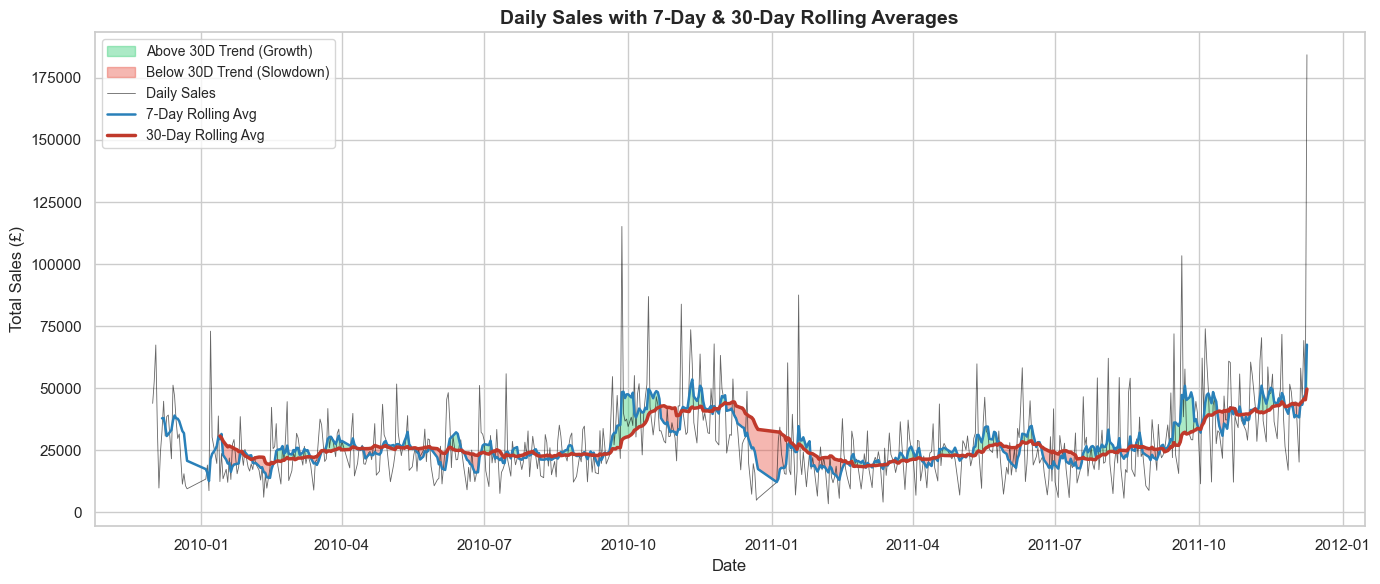

In [44]:
# Plot the rolling statistics
plt.figure(figsize=(14, 6))

# Fill between 7D and 30D averages to highlight trend crossovers
plt.fill_between(
    daily_sales['InvoiceDate'],
    daily_sales['Rolling_7D_Avg'],
    daily_sales['Rolling_30D_Avg'],
    where=daily_sales['Rolling_7D_Avg'] >= daily_sales['Rolling_30D_Avg'],
    color='#2ecc71', alpha=0.4, interpolate=True, label='Above 30D Trend (Growth)'
)
plt.fill_between(
    daily_sales['InvoiceDate'],
    daily_sales['Rolling_7D_Avg'],
    daily_sales['Rolling_30D_Avg'],
    where=daily_sales['Rolling_7D_Avg'] < daily_sales['Rolling_30D_Avg'],
    color='#e74c3c', alpha=0.4, interpolate=True, label='Below 30D Trend (Slowdown)'
)

# Daily sales 
sns.lineplot(data=daily_sales, x='InvoiceDate', y='TotalPrice', 
             color='#000000', label='Daily Sales', alpha=0.6, linewidth=0.6)

# 7-day rolling 
sns.lineplot(data=daily_sales, x='InvoiceDate', y='Rolling_7D_Avg', 
             color='#2980b9', label='7-Day Rolling Avg', linewidth=1.8)

# 30-day rolling
sns.lineplot(data=daily_sales, x='InvoiceDate', y='Rolling_30D_Avg', 
             color='#c0392b', label='30-Day Rolling Avg', linewidth=2.5)

plt.title('Daily Sales with 7-Day & 30-Day Rolling Averages', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Total Sales (£)', fontsize=12)
plt.legend(title='', fontsize=10, loc='upper left')
plt.tight_layout()
plt.show()

## 5. Data Validation with Great Expectations
Before we use our RFM features for modeling, we need to validate them. 
`great_expectations` allows us to define strict rules (expectations) about what our data should look like.


In [45]:
# --- Quick sanity check ---
print("🔍 Missing Values per DataFrame:\n")
print("=" * 40)

print("\n📦 df (transactions):")
print(df.isnull().sum())

print("\n📊 rfm (customer scores):")
print(rfm.isnull().sum())

print("\n📈 daily_sales (features):")
print(daily_sales.isnull().sum())

🔍 Missing Values per DataFrame:


📦 df (transactions):
InvoiceNo           0
StockCode           0
Description      4275
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     235151
Country             0
TotalPrice          0
Year                0
Month               0
Day                 0
Hour                0
YearMonth           0
dtype: int64

📊 rfm (customer scores):
CustomerID    0
Recency       0
Frequency     0
Monetary      0
dtype: int64

📈 daily_sales (features):
InvoiceDate         0
TotalPrice          0
Rolling_7D_Avg      6
Rolling_30D_Avg    29
dtype: int64


In [46]:
print("\n" + "=" * 40)
print("🔍 Validating cleaned transaction data:\n")

transaction_checks = {
    'CustomerID not null': purchases['CustomerID'].notna().all(),
    'Quantity > 0': (purchases['Quantity'] > 0).all(),
    'UnitPrice >= 0': (purchases['UnitPrice'] >= 0).all(),
}

for description, result in transaction_checks.items():
    status = '✅' if result else '❌'
    print(f"{status} {description}: {result}")


🔍 Validating cleaned transaction data:

✅ CustomerID not null: True
✅ Quantity > 0: True
✅ UnitPrice >= 0: True


In [47]:
print("\n" + "=" * 40)
print("🔍 Validating RFM features with Great Expectations...\n")

context = gx.get_context() # central object that manages data sources, suites, and validations
validator = context.data_sources.add_pandas("rfm_pandas") \
    .add_dataframe_asset("rfm_asset") \
    .add_batch_definition_whole_dataframe("rfm_batch") \
    .get_batch(batch_parameters={"dataframe": rfm})

suite = gx.ExpectationSuite(name="rfm_validation_suite") # Container that holds all the validation rules 
suite.add_expectation(gx.expectations.ExpectColumnValuesToBeUnique(column="CustomerID"))
suite.add_expectation(gx.expectations.ExpectColumnValuesToNotBeNull(column="CustomerID"))
suite.add_expectation(gx.expectations.ExpectColumnValuesToBeBetween(column="Recency", min_value=1, max_value=None))
suite.add_expectation(gx.expectations.ExpectColumnValuesToBeBetween(column="Frequency", min_value=1, max_value=None))
suite.add_expectation(gx.expectations.ExpectColumnValuesToBeBetween(column="Monetary", min_value=0.001, max_value=None))
validation_result = validator.validate(suite)

labels = [
    ('CustomerID', 'Values unique'), ('CustomerID', 'Not null'),
    ('Recency', 'Min >= 1'), ('Frequency', 'Min >= 1'), ('Monetary', 'Min > 0'),
]
results = []
for i, (col, check) in enumerate(labels):
    r = validation_result.results[i]
    try:
        s = r.success
        if callable(s): s = s()
    except:
        s = False
    results.append({'Column': col, 'Check': check, 'Result': '✅' if s else '❌'})
display(pd.DataFrame(results))

overall = validation_result.success
if callable(overall): overall = overall()
print("\n✅ All validations passed! Data is clean and ready for analysis." if overall 
      else "\n⚠️  Some validations failed. Please review before proceeding.")


🔍 Validating RFM features with Great Expectations...



Calculating Metrics: 100%|██████████| 34/34 [00:00<00:00, 638.68it/s]


,Column,Check,Result
0,CustomerID,Values unique,✅
1,CustomerID,Not null,✅
2,Recency,Min >= 1,✅
3,Frequency,Min >= 1,✅
4,Monetary,Min > 0,✅



✅ All validations passed! Data is clean and ready for analysis.


## 6. Key Takeaways

- **Missing CustomerIDs handled transparently**: 235,151 rows (~22% of transactions) excluded — necessary for customer-level RFM, but their revenue impact warrants separate analysis.
- **Cancellations excluded from RFM**: Return transactions (`Quantity ≤ 0`) are dropped so Frequency and Monetary scores reflect genuine purchase behavior.
- **RFM features engineered**: Each customer now has Recency, Frequency, and Monetary scores — ready for segmentation and clustering.
- **Rolling averages reveal trend shifts**: Green zones show when short-term performance exceeds the long-term baseline; pink zones highlight underperformance periods.
- **All validations passed**: Transaction data is clean (no null IDs, no negative quantities); RFM features meet all threshold requirements.
- **Data is modeling-ready**: Validated features are saved for the next phase (Clustering & Customer Segmentation).

## 7. Save Validated Features
Since our features passed validation, we can safely save them for the next phase.

In [48]:
os.makedirs('../data/processed', exist_ok=True)

rfm.to_csv('../data/processed/rfm_features.csv', index=False)
daily_sales.to_csv('../data/processed/daily_sales_features.csv', index=False)

print("✅ RFM features saved to ../data/processed/rfm_features.csv")
print("✅ Daily sales features saved to ../data/processed/daily_sales_features.csv")

✅ RFM features saved to ../data/processed/rfm_features.csv
✅ Daily sales features saved to ../data/processed/daily_sales_features.csv
